## Define Task and Inspect the Data

In this assignment, we are given an xray image of a patient and we need to classify whether the patient has a pneumonia disease. There are 3 input data that is given, which is the dicom file containing the image of the xray with some other metadata. The second input is a csv file containing the label of the image and the bounding box of where the pneumonia is detected. The third input is a csv file that contains the mapping of the rsna to nih id  

TODO what is third csv

## Set Seed

In [23]:
import random
import numpy as np
import torch

SEED = 67

def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)

    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(SEED)

### Data Loading

In [24]:
from pathlib import Path
DATA_ROOT = Path("data/images")
LABEL_FILE = Path("assignment1_labels.csv")
MAPPING_FILE = Path("rsna_to_nih_mapping.csv")

In [25]:
dicom_files = sorted(DATA_ROOT.rglob("*.dcm"))
print("DICOM files found:", len(dicom_files))
print("Label file found:", LABEL_FILE.exists())

print("Mapping file found:", MAPPING_FILE.exists())
assert len(dicom_files) > 0, "No DICOM files were found."
assert LABEL_FILE.exists(), "The label file was not found."
assert MAPPING_FILE.exists(), "The mapping file was not found."

DICOM files found: 25684
Label file found: True
Mapping file found: True


### Inspect Data

In [26]:
import pandas as pd
import pydicom

metadata_path = Path("data/dicom_metadata.parquet")

if metadata_path.exists():
    print(f"Loading metadata from {metadata_path}")
    metadata_df = pd.read_parquet(metadata_path)

else:
    print("Creating metadata file...")

    metadata_list = []

    for path in dicom_files:
        # metadata only—avoid loading large pixel arrays
        ds = pydicom.dcmread(path, stop_before_pixels=True)

        metadata_list.append({
            "File Path": str(path),
            "Patient ID": str(ds.get("PatientID", "")),
            "SOP Instance UID": str(ds.get("SOPInstanceUID", "")),
            "Study Instance UID": str(ds.get("StudyInstanceUID", "")),
            "Study Date": str(ds.get("StudyDate", "")),
            "Series Instance UID": str(ds.get("SeriesInstanceUID", "")),
            "Modality": str(ds.get("Modality", "")),
            "Body Part Examined": str(ds.get("BodyPartExamined", "")),
            "Manufacturer": str(ds.get("Manufacturer", "")),
            "Rows": ds.get("Rows", pd.NA),
            "Columns": ds.get("Columns", pd.NA),
            "Photometric Interpretation": str(
                ds.get("PhotometricInterpretation", "")
            ),
            "View Position": str(ds.get("ViewPosition", ""))
        })

    metadata_df = pd.DataFrame(metadata_list)

    metadata_df.to_parquet(metadata_path, index=False)
    print(f"Metadata saved to {metadata_path}")

metadata_df.head()

Loading metadata from data/dicom_metadata.parquet


,File Path,Patient ID,SOP Instance UID,Study Instance UID,Study Date,Series Instance UID,Modality,Body Part Examined,Manufacturer,Rows,Columns,Photometric Interpretation,View Position
0,data/images/1.2.276.0.7230010.3.1.2.8323329.10...,4af96201-f655-4ee8-af0c-0cd3cbe64df7,1.2.276.0.7230010.3.1.4.8323329.10001.15178743...,1.2.276.0.7230010.3.1.2.8323329.10001.15178743...,19010101,1.2.276.0.7230010.3.1.3.8323329.10001.15178743...,CR,CHEST,,1024,1024,MONOCHROME2,AP
1,data/images/1.2.276.0.7230010.3.1.2.8323329.10...,ee9c1ee7-38c3-45f0-ac3b-5bdda1fc4223,1.2.276.0.7230010.3.1.4.8323329.10002.15178743...,1.2.276.0.7230010.3.1.2.8323329.10002.15178743...,19010101,1.2.276.0.7230010.3.1.3.8323329.10002.15178743...,CR,CHEST,,1024,1024,MONOCHROME2,PA
2,data/images/1.2.276.0.7230010.3.1.2.8323329.10...,90519cd3-09c1-4c20-92b7-f494a19f0ae0,1.2.276.0.7230010.3.1.4.8323329.10004.15178743...,1.2.276.0.7230010.3.1.2.8323329.10004.15178743...,19010101,1.2.276.0.7230010.3.1.3.8323329.10004.15178743...,CR,CHEST,,1024,1024,MONOCHROME2,AP
3,data/images/1.2.276.0.7230010.3.1.2.8323329.10...,4d839a29-e065-431c-8cdc-9277432c966f,1.2.276.0.7230010.3.1.4.8323329.10005.15178743...,1.2.276.0.7230010.3.1.2.8323329.10005.15178743...,19010101,1.2.276.0.7230010.3.1.3.8323329.10005.15178743...,CR,CHEST,,1024,1024,MONOCHROME2,PA
4,data/images/1.2.276.0.7230010.3.1.2.8323329.10...,75ed8091-a23e-4dba-84fa-014f5920e9a5,1.2.276.0.7230010.3.1.4.8323329.10006.15178743...,1.2.276.0.7230010.3.1.2.8323329.10006.15178743...,19010101,1.2.276.0.7230010.3.1.3.8323329.10006.15178743...,CR,CHEST,,1024,1024,MONOCHROME2,PA


In [27]:
mapping_df = pd.read_csv(MAPPING_FILE, dtype=str)

# The mapping file's patientId matches the DICOM SOPInstanceUID.
# Use the mapped NIH patient ID to count distinct patients.
available_mapping = mapping_df[
    mapping_df["patientId"].isin(metadata_df["SOP Instance UID"])
]

n_instances = len(metadata_df)
n_rsna_image_ids = metadata_df["SOP Instance UID"].nunique()
n_patients = available_mapping["nih_patient_id"].nunique()
n_studies = metadata_df["Study Instance UID"].nunique()
n_series = metadata_df["Series Instance UID"].nunique()

print(f"Number of instances: {n_instances}")
print(f"Number of unique RSNA image IDs: {n_rsna_image_ids}")
print(f"Number of unique NIH patients: {n_patients}")
print(f"Number of studies: {n_studies}")
print(f"Number of series: {n_series}")

Number of instances: 25684
Number of unique RSNA image IDs: 25684
Number of unique NIH patients: 11171
Number of studies: 25684
Number of series: 25684


There are 11171 unique patients based on the rsna to nih mapping csv file so we need to consider this at splitting the data

In [28]:
available_mapping.head()

,patientId,nih_patient_id,nih_image_id
0,1.2.276.0.7230010.3.1.4.8323329.10001.15178743...,00011683,00011683_018.png
1,1.2.276.0.7230010.3.1.4.8323329.10002.15178743...,00002245,00002245_000.png
2,1.2.276.0.7230010.3.1.4.8323329.10004.15178743...,00030355,00030355_000.png
3,1.2.276.0.7230010.3.1.4.8323329.10005.15178743...,00014758,00014758_000.png
4,1.2.276.0.7230010.3.1.4.8323329.10006.15178743...,00004082,00004082_008.png


In [29]:
# aggregate several bounding box, use ai
import pandas as pd

annotation_df = pd.read_csv(LABEL_FILE)

study_to_path = metadata_df.set_index("Study Instance UID")["File Path"]
annotation_df["File Path"] = annotation_df["StudyInstanceUID"].map(study_to_path)

sop_id_to_nih_id = available_mapping.set_index("patientId")["nih_patient_id"]
annotation_df["nih_patient_id"] = annotation_df["SOPInstanceUID"].map(sop_id_to_nih_id)

# Store each positive annotation as a dictionary. Negative images have no box.
def make_bounding_box(row):
    if row["Target"] == 0:
        return None
    return {
        "x": int(row["x"]),
        "y": int(row["y"]),
        "width": int(row["width"]),
        "height": int(row["height"])
    }

annotation_df["Bounding Box"] = annotation_df.apply(make_bounding_box, axis=1)

# The classification label must be consistent across all rows for an image.
assert annotation_df.groupby("SOPInstanceUID")["Target"].nunique().max() == 1

# Create one row per image and preserve all of its bounding boxes in a list.
label_df = (
    annotation_df
    .groupby("SOPInstanceUID", as_index=False, sort=False)
    .agg(**{
        "patientId": ("patientId", "first"),
        "StudyInstanceUID": ("StudyInstanceUID", "first"),
        "SeriesInstanceUID": ("SeriesInstanceUID", "first"),
        "Target": ("Target", "first"),
        "File Path": ("File Path", "first"),
        "nih_patient_id": ("nih_patient_id", "first"),
        "Bounding Boxes": ("Bounding Box", lambda boxes: [
            box for box in boxes if box is not None
        ])
    })
)

display(label_df.head())
display(mapping_df.head())

print("Annotation rows:", len(annotation_df))
print("Unique images:", len(label_df))
print("Images with multiple boxes:", label_df["Bounding Boxes"].apply(len).gt(1).sum())
print("Images without a DICOM file:", label_df["File Path"].isna().sum())

,SOPInstanceUID,patientId,StudyInstanceUID,SeriesInstanceUID,Target,File Path,nih_patient_id,Bounding Boxes
0,1.2.276.0.7230010.3.1.4.8323329.5872.151787431...,1.2.276.0.7230010.3.1.4.8323329.5872.151787431...,1.2.276.0.7230010.3.1.2.8323329.5872.151787431...,1.2.276.0.7230010.3.1.3.8323329.5872.151787431...,0,data/images/1.2.276.0.7230010.3.1.2.8323329.58...,00020276,[]
1,1.2.276.0.7230010.3.1.4.8323329.15466.15178743...,1.2.276.0.7230010.3.1.4.8323329.15466.15178743...,1.2.276.0.7230010.3.1.2.8323329.15466.15178743...,1.2.276.0.7230010.3.1.3.8323329.15466.15178743...,0,data/images/1.2.276.0.7230010.3.1.2.8323329.15...,00003755,[]
2,1.2.276.0.7230010.3.1.4.8323329.10973.15178743...,1.2.276.0.7230010.3.1.4.8323329.10973.15178743...,1.2.276.0.7230010.3.1.2.8323329.10973.15178743...,1.2.276.0.7230010.3.1.3.8323329.10973.15178743...,1,data/images/1.2.276.0.7230010.3.1.2.8323329.10...,00006774,"[{'x': 564, 'y': 356, 'width': 274, 'height': ..."
3,1.2.276.0.7230010.3.1.4.8323329.22658.15178744...,1.2.276.0.7230010.3.1.4.8323329.22658.15178744...,1.2.276.0.7230010.3.1.2.8323329.22658.15178744...,1.2.276.0.7230010.3.1.3.8323329.22658.15178744...,0,data/images/1.2.276.0.7230010.3.1.2.8323329.22...,00004413,[]
4,1.2.276.0.7230010.3.1.4.8323329.18672.15178744...,1.2.276.0.7230010.3.1.4.8323329.18672.15178744...,1.2.276.0.7230010.3.1.2.8323329.18672.15178744...,1.2.276.0.7230010.3.1.3.8323329.18672.15178744...,1,data/images/1.2.276.0.7230010.3.1.2.8323329.18...,00008037,"[{'x': 582, 'y': 315, 'width': 358, 'height': ..."


,patientId,nih_patient_id,nih_image_id
0,1.2.276.0.7230010.3.1.4.8323329.10001.15178743...,00011683,00011683_018.png
1,1.2.276.0.7230010.3.1.4.8323329.10002.15178743...,00002245,00002245_000.png
2,1.2.276.0.7230010.3.1.4.8323329.10004.15178743...,00030355,00030355_000.png
3,1.2.276.0.7230010.3.1.4.8323329.10005.15178743...,00014758,00014758_000.png
4,1.2.276.0.7230010.3.1.4.8323329.10006.15178743...,00004082,00004082_008.png


Annotation rows: 28989
Unique images: 25684
Images with multiple boxes: 3178
Images without a DICOM file: 0


In [30]:
# Class counts and proportion
pd.DataFrame({
    "Class Count": label_df['Target'].value_counts(),
    "Class Percentage": label_df['Target'].value_counts() / len(label_df),
})

,Class Count,Class Percentage
Target,,
0,20025,0.779668
1,5659,0.220332


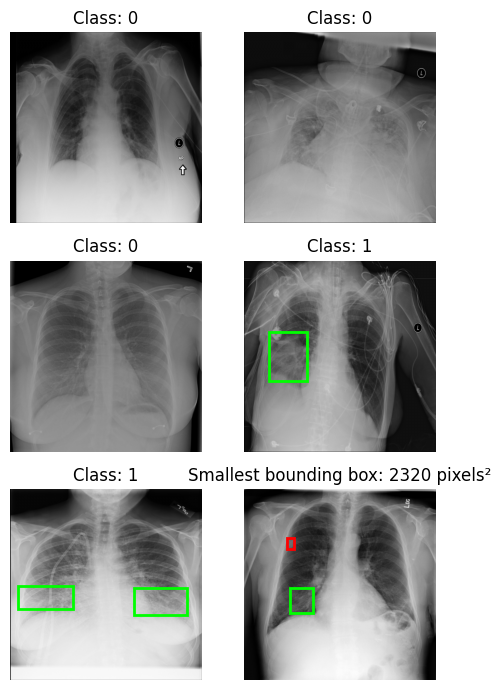

In [31]:
# Display at least six representative images: positive and negative examples, and the one with the smallest bounding box

import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

positive_df = label_df[label_df["Target"] == 1].copy()
negative_df = label_df[label_df["Target"] == 0].copy()

# Locate the smallest box while retaining every box for its image.
positive_df["Smallest Box Area"] = positive_df["Bounding Boxes"].apply(
    lambda boxes: min(box["width"] * box["height"] for box in boxes)
)
smallest_row = positive_df.loc[positive_df["Smallest Box Area"].idxmin()]
smallest_box = min(
    smallest_row["Bounding Boxes"],
    key=lambda box: box["width"] * box["height"]
)
smallest_image_id = smallest_row["SOPInstanceUID"]

# Select three unique negatives and two other unique positives
negative_examples = (
    negative_df
    .sample(3, random_state=42)
)

positive_examples = (
    positive_df[positive_df["SOPInstanceUID"] != smallest_image_id]
    .sample(2, random_state=42)
)

displayed_dicom = pd.concat([
    negative_examples,
    positive_examples,
    smallest_row.to_frame().T
])

fig, axes = plt.subplots(3, 2, figsize=(5, 7))

for i, (_, row) in enumerate(displayed_dicom.iterrows()):
    ds = pydicom.dcmread(row["File Path"])
    image = ds.pixel_array

    ax = axes.flat[i]
    ax.imshow(image, cmap="gray")
    ax.set_title(f"Class: {row['Target']}")
    ax.axis("off")

    # Draw every box belonging to the image.
    for bounding_box in row["Bounding Boxes"]:
        is_smallest = i == 5 and bounding_box == smallest_box
        rectangle = Rectangle(
            (bounding_box["x"], bounding_box["y"]),
            bounding_box["width"],
            bounding_box["height"],
            edgecolor="red" if is_smallest else "lime",
            facecolor="none",
            linewidth=2
        )
        ax.add_patch(rectangle)

    if i == 5:
        ax.set_title(
            f"Smallest bounding box: {int(row['Smallest Box Area'])} pixels²"
        )

plt.tight_layout()
plt.show()

In [32]:
# Check image size, photometric interpretation and projection/view information when available
print("Image size counts:")
display(metadata_df.value_counts(["Rows", "Columns"], dropna=False).rename("Count").reset_index())

print("Photometric interpretation counts:")
display(metadata_df["Photometric Interpretation"].value_counts(dropna=False))

print("Projection/view counts:")
display(metadata_df["View Position"].value_counts(dropna=False)) # AP is Anterior Posterior / from the front

Image size counts:


,Rows,Columns,Count
0,1024,1024,25684


Photometric interpretation counts:


Photometric Interpretation
MONOCHROME2    25684
Name: count, dtype: int64

Projection/view counts:


View Position
PA    13979
AP    11705
Name: count, dtype: int64

## Create Splits

In [33]:


# train, val, and test split based on NIH data
from sklearn.model_selection import GroupShuffleSplit

split1 = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=67)
train_idx, temp_idx = next(split1.split(label_df, groups=label_df["nih_patient_id"]))

train_df = label_df.iloc[train_idx].reset_index(drop=True)
temp_df = label_df.iloc[temp_idx].reset_index(drop=True)

split2 = GroupShuffleSplit(n_splits=1, test_size=0.5, random_state=67)
val_idx, test_idx = next(split2.split(temp_df, groups=temp_df['nih_patient_id']))

val_df = temp_df.iloc[val_idx].reset_index(drop=True)
test_df = temp_df.iloc[test_idx].reset_index(drop=True)

print(f"Train: {len(train_df)}, val: {len(val_df)}, test: {len(test_df)}")

# positive class proportion
print("Train")
display(train_df['Target'].value_counts() / len(train_df['Target']))
print("Val")
display(val_df['Target'].value_counts() / len(val_df['Target']))
print("Test")
display(test_df['Target'].value_counts() / len(test_df['Target']))

# verify no overlap
train_patients = set(train_df['nih_patient_id'])
val_patients = set(val_df['nih_patient_id'])
test_patients = set(test_df['nih_patient_id'])

assert(len(train_patients & val_patients) == 0)
assert(len(train_patients & test_patients) == 0)
assert(len(test_patients & val_patients) == 0)

print("Train-Val overlap:", train_patients & val_patients)
print("Train-Test overlap:", train_patients & test_patients)
print("Val-Test overlap:", val_patients & test_patients)

Train: 20658, val: 2480, test: 2546
Train


Target
0    0.779117
1    0.220883
Name: count, dtype: float64

Val


Target
0    0.774597
1    0.225403
Name: count, dtype: float64

Test


Target
0    0.789081
1    0.210919
Name: count, dtype: float64

Train-Val overlap: set()
Train-Test overlap: set()
Val-Test overlap: set()


In multi site dataset, there might be a leakage where the model already learn the pattern from all of the site on the data thus it might overfit to test data and perform poorly when used on site/place outside the collected data or in real world application. To handle this, we also need to consider the site on to the splitting, such as by excluding the data from a certain site on the train data so the test data result can reduce this impact

## Preprocessing and Augmentation

In [34]:
# convert dicom to tensor
# we use dataset so the data will gradually loaded to the ram when needed
import torch
from torch.utils.data import Dataset, DataLoader
import numpy as np

DEVICE = torch.device("cuda")
BATCH_SIZE = 64
NUM_WORKERS = 4

class DICOM_dataset(Dataset):
    def __init__(self, df, image_col, label_col, transform=None):
        self.df = df.reset_index(drop=True)
        self.image_col = image_col
        self.label_col = label_col
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, index):
        path = self.df.loc[index, self.image_col]

        dcm = pydicom.dcmread(path)
        image = dcm.pixel_array.astype(np.float32)

        # rescale
        slope = float(getattr(dcm, "RescaleSlope", 1.0))
        intercept = float(getattr(dcm, "RescaleIntercept", 0.0))
        image = image * slope + intercept

        # normalize
        min_val = image.min()
        max_val = image.max()
        image = (image - min_val) / (max_val - min_val)

        image = torch.from_numpy(image).float().unsqueeze(0)
        image = image.repeat(3, 1, 1) # [3, H, W] so that it can be processed by resnet

        if self.transform:
            image = self.transform(image)

        label = self.df.loc[index, self.label_col]
        label = torch.tensor(label, dtype=torch.float32)

        return image, label


In [35]:
# training only augmentation
import torchvision.transforms as T
from torchvision.transforms import InterpolationMode

eval_transform = T.Compose([
    T.Resize(
        (224, 224),
        interpolation=InterpolationMode.BILINEAR,
        antialias=True
    ),
    T.Normalize(
        mean=[0.485, 0.456, 0.406], # given by the imagenet dataset
        std=[0.229, 0.224, 0.225]
    )
])

train_transform = T.Compose([
    T.Resize(
        (224, 224),
        interpolation=InterpolationMode.BILINEAR,
        antialias=True
    ),
    T.RandomRotation(degrees=7, interpolation=InterpolationMode.BILINEAR,),
    T.RandomAffine(
        degrees=0,
        translate=(0.03, 0.03),
        scale=(0.95, 1.05)
    ),
    T.RandomApply([
        T.ColorJitter(
            brightness=0.1,
            contrast=0.1
        )
    ], p=0.5),
    T.Normalize(
        mean=[0.485, 0.456, 0.406], # given by the imagenet dataset
        std=[0.229, 0.224, 0.225]
    )
])

In [36]:
train_dataset = DICOM_dataset(train_df, "File Path", "Target", transform=train_transform)
val_dataset = DICOM_dataset(val_df, "File Path", "Target", transform=eval_transform)
test_dataset = DICOM_dataset(test_df, "File Path", "Target", transform=eval_transform)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    # pin_memory=True,
    # persistent_workers=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    # pin_memory=True,
    # persistent_workers=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    # pin_memory=True,
    # persistent_workers=True
)

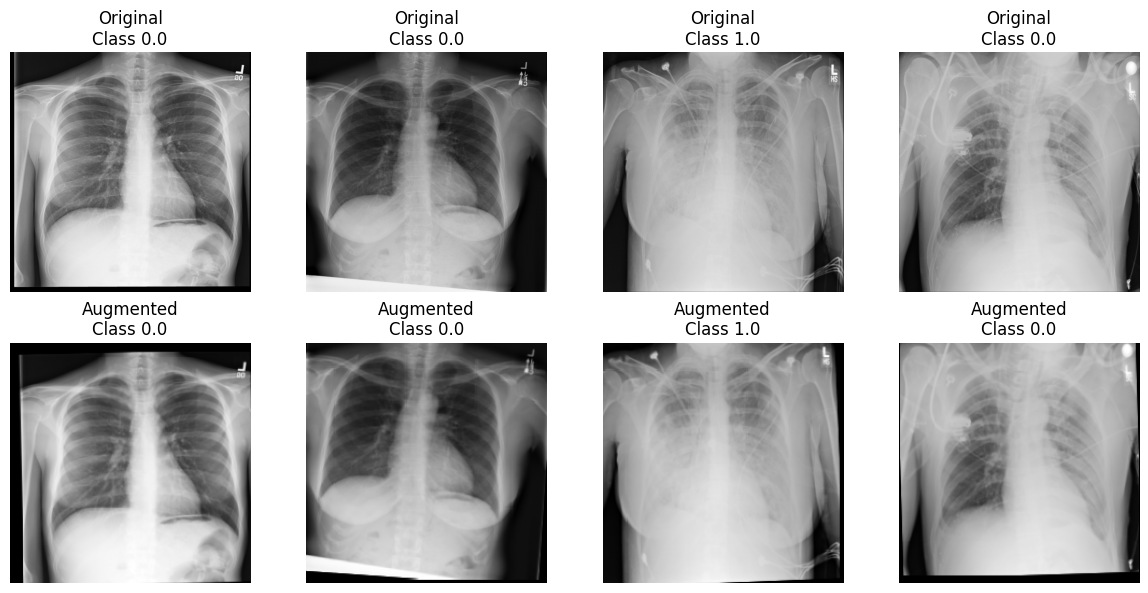

In [37]:
# example of train data with and without transform

train_dataset_transform = DICOM_dataset(train_df, "File Path", "Target", transform=train_transform)
train_transform_loader = DataLoader(
    train_dataset_transform,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0
)

train_dataset_no_transform = DICOM_dataset(train_df, "File Path", "Target")
train_no_transform_loader = DataLoader(
    train_dataset_no_transform,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0
)

images_no_transform, labels_no_transform = next(iter(train_no_transform_loader))
images_transform, labels_transform = next(iter(train_transform_loader))

fig, axes = plt.subplots(2, 4, figsize=(12, 6))

for i in range(4):
    # Original
    axes[0, i].imshow(
        images_no_transform[i][0].squeeze().cpu().numpy(),
        cmap="gray"
    )
    axes[0, i].set_title(f"Original\nClass {labels_no_transform[i].item()}")
    axes[0, i].axis("off")

    # Augmented
    axes[1, i].imshow(
        images_transform[i][0].squeeze().cpu().numpy(),
        cmap="gray"
    )
    axes[1, i].set_title(f"Augmented\nClass {labels_transform[i].item()}")
    axes[1, i].axis("off")

plt.tight_layout()
plt.show()

## Trivial Baseline

In [38]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, recall_score, f1_score, precision_score

def evaluate(labels, probabilities, threshold=0.5):
    predictions = (probabilities >= threshold).astype(int)

    conf_matrix = confusion_matrix(labels, predictions)
    tn, fp, fn, tp = conf_matrix.copy().ravel()

    return {
        "labels": labels,
        "probabilities": probabilities,
        "predictions": predictions,
        "confusion_matrix": conf_matrix,
        "accuracy": accuracy_score(labels, (probabilities >= 0.5).astype(int)),
        "sensitivity": recall_score(labels, predictions),
        "specificity": tn / (tn + fp),
        "precision": precision_score(labels, predictions),
        "roc_auc": roc_auc_score(labels, probabilities),        
        "f1_score": f1_score(labels, (probabilities >= 0.5).astype(int), average="macro")
    }

## Simple Baseline

In [39]:
# extract numerical features from the image
def extract_feature_from_loader(loader, n_bins=32):
    X = []
    y = []

    for images, labels in loader:
        for image, label in zip(images, labels):
            pixels = image[0].squeeze().cpu().numpy().astype(np.float32) # just take one channel
            flat = pixels.ravel()

            features = [
                np.mean(flat),
                np.median(flat),
                np.std(flat),
                np.min(flat),
                np.max(flat),
                np.percentile(flat, 25),
                np.percentile(flat, 75),
            ]

            hist, _ = np.histogram(
                flat,
                bins=n_bins,
                range=(0, 1),
                density=True
            )

            features = np.concatenate([np.array(features),hist])
            X.append(features)
            y.append(label.item())

    return np.array(X), np.array(y)

In [40]:
# load feature if already ran before since it could take a while to run the extraction
import os

FEATURE_FILE = "data/xray_rf_features_image_level.npz"

if os.path.exists(FEATURE_FILE):
    print("loading saved features...")

    data = np.load(FEATURE_FILE)

    X_train = data["X_train"]
    y_train = data["y_train"]

    X_val = data["X_val"]
    y_val = data["y_val"]

    X_test = data["X_test"]
    y_test = data["y_test"]

else:
    print("Feature file not found. Extracting features...")

    X_train, y_train = extract_feature_from_loader(train_loader)
    X_val, y_val = extract_feature_from_loader(val_loader)
    X_test, y_test = extract_feature_from_loader(test_loader)

    print("Saving features...")

    np.savez_compressed(
        FEATURE_FILE,
        X_train=X_train,
        y_train=y_train,
        X_val=X_val,
        y_val=y_val,
        X_test=X_test,
        y_test=y_test
    )

    print(f"Saved to {FEATURE_FILE}")

print("Train:", X_train.shape, y_train.shape)
print("Val:  ", X_val.shape, y_val.shape)
print("Test: ", X_test.shape, y_test.shape)

loading saved features...
Train: (20658, 39) (20658,)
Val:   (2480, 39) (2480,)
Test:  (2546, 39) (2546,)


In [41]:
# from sklearn.ensemble import RandomForestClassifier
# from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, recall_score

# rf_model = RandomForestClassifier(n_estimators=100, random_state=67)
# rf_model.fit(X_train, y_train)

# y_val_pred = rf_model.predict(X_val)

# accuracy = accuracy_score(y_val, y_val_pred)
# classification_rep = classification_report(y_val, y_val_pred)

# print(f"Accuracy: {accuracy:.2f}")
# print("\nClassification Report:\n", classification_rep)

In [42]:
# # try tuning hyperparam with val and final eval with test
# from sklearn.model_selection import RandomizedSearchCV

# param_distributions = {
#     "n_estimators": [100, 200, 500],
#     "max_depth": [None, 5, 10, 30],
#     "min_samples_split": [2, 5, 10],
#     "min_samples_leaf": [1, 2, 4],
#     "class_weight": [None, "balanced"]
# }

# rf_model = RandomForestClassifier(n_estimators=100, random_state=67)
# random_search = RandomizedSearchCV(rf_model, param_distributions, n_iter=5, scoring="recall", random_state=67)

# random_search.fit(X_train, y_train)

# best_rf_model = random_search.best_estimator_
# y_val_pred = best_rf_model.predict(X_val)

# print("Best parameters:", random_search.best_params_)
# print(f"Accuracy: {accuracy_score(y_val, y_val_pred):.2f}")
# print("\nClassification Report:\n", classification_report(y_val, y_val_pred))

In [43]:
# # eval on test data
# y_test_pred = best_rf_model.predict(X_test)

# print("Best parameters:", random_search.best_params_)
# print(f"Accuracy: {accuracy_score(y_test, y_test_pred):.2f}")
# print("\nClassification Report:\n", classification_report(y_test, y_test_pred))
# print(f"Recall: {recall_score(y_test, y_test_pred)}")

try 3 seeds

In [ ]:
# ai to save and load the joblib
import os
import joblib
from sklearn.ensemble import RandomForestClassifier

THREE_SEEDS = [1, 2, 3]

os.makedirs("model", exist_ok=True)

rf_results = []

for seed in THREE_SEEDS:
    model_path = f"model/random_forest_seed_{seed}.joblib"

    if os.path.exists(model_path):
        print(f"Loading {model_path}")
        rf_model = joblib.load(model_path)
    else:
        print(f"Training Random Forest (seed={seed})")

        rf_model = RandomForestClassifier(
            n_estimators=500,
            min_samples_split=2,
            min_samples_leaf=4,
            max_depth=None,
            class_weight="balanced",
            random_state=seed
        )

        rf_model.fit(X_train, y_train)

        joblib.dump(rf_model, model_path)
        print(f"Saved to {model_path}")

    y_val_prob = rf_model.predict_proba(X_val)[:, 1]
    
    rf_results.append(evaluate(y_val, y_val_prob))

Loading model/random_forest_seed_1.joblib


Loading model/random_forest_seed_2.joblib
Loading model/random_forest_seed_3.joblib


In [45]:
rf_results_sensitivity = np.array([rf_results[i]['sensitivity'] for i in range(len(THREE_SEEDS))])
print(f"RF sensitivity mean: {rf_results_sensitivity.mean()}, std: {rf_results_sensitivity.std()}")

RF sensitivity mean: 0.40310077519379844, std: 0.0008432996794114851


## Pretrained CNN (Resnet50 from pytorch)

In [46]:
import torch.nn as nn
from torchvision import models

def make_resnet50():
    resnet_model = models.resnet50(
        weights='IMAGENET1K_V2'
    )

    # freeze everything
    for param in resnet_model.parameters():
        param.requires_grad = False

    # unfreeze the final ResNet block
    for param in resnet_model.layer4.parameters():
        param.requires_grad = True

    fc_input_dim = resnet_model.fc.in_features
    resnet_model.fc = nn.Linear(fc_input_dim, 1)
    resnet_model.to(DEVICE)

    return resnet_model

resnet_model = make_resnet50()

In [47]:
total_params = sum(p.numel() for p in resnet_model.parameters())

trainable_params = sum(
    p.numel() for p in resnet_model.parameters()
    if p.requires_grad
)

frozen_params = total_params - trainable_params

print(f"Total parameters:     {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")
print(f"Frozen parameters:    {frozen_params:,}")

Total parameters:     23,510,081
Trainable parameters: 14,966,785
Frozen parameters:    8,543,296


In [48]:
def run_epoch(model, loader, criterion, optimizer=None):
    training = optimizer is not None
    model.train(training)
    total_loss = 0.0

    for x, y in loader:
        x = x.to(DEVICE, non_blocking=True)
        y = y.to(DEVICE, non_blocking=True).float().reshape(-1)
        if training:
            optimizer.zero_grad()
        logits = model(x).reshape(-1)
        loss = criterion(logits, y)
        if training:
            loss.backward()
            optimizer.step()
        total_loss += loss.item() * len(x)
    return total_loss / len(loader.dataset)


def train_model(model, epochs, learning_rate, weight_decay, pos_weight=None, checkpoint_path="best_model.pth", seed = SEED):
    set_seed(seed) # set global seed
    
    optimizer = torch.optim.AdamW(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=learning_rate,
        weight_decay=weight_decay
    )

    if pos_weight != None:
        criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
    else:
        criterion = nn.BCEWithLogitsLoss()

    best_val_loss = float("inf")
    best_epoch = 0

    history = {"train": [], "validation": []}
    for epoch in range(epochs):
        train_loss = run_epoch(model, train_loader, criterion, optimizer)
        with torch.no_grad():
            validation_loss = run_epoch(model, val_loader, criterion)
        history["train"].append(train_loss)
        history["validation"].append(validation_loss)

        if validation_loss < best_val_loss:
            best_val_loss = validation_loss
            best_epoch = epoch + 1

            torch.save(model.state_dict(), checkpoint_path)

            print("Save best model, ", end='')

        print(f"Epoch {epoch + 1}: train loss={train_loss:.4f}, validation loss={validation_loss:.4f}")

    model.load_state_dict(torch.load(checkpoint_path, map_location=DEVICE))
    
    print(f"Best Epoch: {best_epoch}, Best Val Loss: {best_val_loss}")
    
    return history

In [49]:
# temp_history = train_model(resnet_model, epochs=5, learning_rate=1e-4, weight_decay=1e-4, checkpoint_path='model_weight/best_model.pth')

# plt.plot(temp_history["train"], marker="o", label="Training")
# plt.plot(temp_history["validation"], marker="o", label="Validation")
# plt.xlabel("Epoch")
# plt.ylabel("Weighted BCE loss")
# plt.title("Resnet learning curves")
# plt.legend()
# plt.show()

Here we can see that the model is overfitting to the training data since the training loss keep decreasing while the validation loss is increasing. Because of this, we need to take/save the model that is the least overfit, which is the one that has the lowest validation loss.

In [50]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, recall_score, f1_score

def evaluate_model(model, loader, threshold=0.5, verbose=True):
    criterion = nn.BCEWithLogitsLoss()
    model.eval()

    total_loss = 0.0
    all_labels = []
    all_probabilities = []

    with torch.inference_mode():
        for x, y in loader:
            x = x.to(DEVICE, non_blocking=True)
            y = y.to(DEVICE, non_blocking=True).float().reshape(-1)

            logits = model(x).reshape(-1)
            loss = criterion(logits, y)

            probabilities = torch.sigmoid(logits)

            total_loss += loss.item() * x.size(0)
            all_labels.append(y.cpu().numpy())
            all_probabilities.append(probabilities.cpu().numpy())

    labels = np.concatenate(all_labels).astype(int)
    probabilities = np.concatenate(all_probabilities)
    predictions = (probabilities >= threshold).astype(int)

    # test_loss = total_loss / len(loader.dataset)

    return evaluate(labels, probabilities, threshold=threshold)

In [51]:
resnet_model.load_state_dict(
    torch.load(
        "model_weight/best_model.pth",
        map_location=DEVICE,
        weights_only=True
    )
)

resnet_model = resnet_model.to(DEVICE)

val_results = evaluate_model(
    resnet_model,
    test_loader,
    threshold=0.5
)

print(val_results)

{'labels': array([1, 0, 1, ..., 1, 0, 0], shape=(2546,)), 'probabilities': array([0.10403923, 0.00937314, 0.86643606, ..., 0.68901116, 0.21257406,
       0.14625058], shape=(2546,), dtype=float32), 'predictions': array([0, 0, 1, ..., 1, 0, 0], shape=(2546,)), 'confusion_matrix': array([[1898,  111],
       [ 272,  265]]), 'accuracy': 0.8495679497250589, 'sensitivity': 0.4934823091247672, 'specificity': np.float64(0.944748631159781), 'precision': 0.7047872340425532, 'roc_auc': np.float64(0.8682502296462937), 'f1_score': 0.7444275568632293}


### Try weighted loss

In [52]:
import torch.nn as nn
from torchvision import models

resnet_model = models.resnet50(
    weights='IMAGENET1K_V2'
)

# freeze everything
for param in resnet_model.parameters():
    param.requires_grad = False

# unfreeze the final ResNet block
for param in resnet_model.layer4.parameters():
    param.requires_grad = True

fc_input_dim = resnet_model.fc.in_features
resnet_model.fc = nn.Linear(fc_input_dim, 1)

resnet_model = resnet_model.to(DEVICE)

In [53]:
num_positive = (train_df["Target"] == 1).sum()
num_negative = (train_df["Target"] == 0).sum()

positive_weight = num_negative / num_positive

print(f"Negative: {num_negative}")
print(f"Positive: {num_positive}")
print(f"Positive weight: {positive_weight:.2f}")

pos_weight = torch.tensor(
    [positive_weight],
    dtype=torch.float32,
    device=DEVICE
)

Negative: 16095
Positive: 4563
Positive weight: 3.53


In [54]:
# temp_history = train_model(resnet_model, epochs=5, learning_rate=1e-4, weight_decay=1e-4, pos_weight=pos_weight, checkpoint_path='model_weight/best_model_weighted.pth')

# plt.plot(temp_history["train"], marker="o", label="Training")
# plt.plot(temp_history["validation"], marker="o", label="Validation")
# plt.xlabel("Epoch")
# plt.ylabel("Weighted BCE loss")
# plt.title("Resnet learning curves")
# plt.legend()
# plt.show()

Here we also see the same result where the model is overfit to the training data.

In [55]:
resnet_model.load_state_dict(
    torch.load(
        "model_weight/best_model_weighted.pth",
        map_location=DEVICE,
        weights_only=True
    )
)

resnet_model = resnet_model.to(DEVICE)

val_results = evaluate_model(
    resnet_model,
    val_loader,
    threshold=0.5
)

As we can see, the previous model (without weight loss adjustment) got 0.49 on the recall score. After we adjust the loss weight according to the number of data (so that it balance), it got a better result in terms of screening with 0.73 on the recall score. Because of this, we will continue with this weighted setup as our main cnn/resnet model

### Run on 3 seeds

In [56]:
# THREE_SEEDS = [1, 2, 3]
# resnet_histories = []

# for seed in THREE_SEEDS:
#     temp_resnet_model = make_resnet50()
#     resnet_histories.append(train_model(temp_resnet_model, epochs=5, learning_rate=1e-4, weight_decay=1e-4, pos_weight=pos_weight, checkpoint_path=f'model_weight/best_model_{seed}.pth', seed=seed))


# for i in range(len(THREE_SEEDS)):
#     plt.plot(resnet_histories[i]["train"], marker="o", label="Training")
#     plt.plot(resnet_histories[i]["validation"], marker="o", label="Validation")
#     plt.xlabel("Epoch")
#     plt.ylabel("Weighted BCE loss")
#     plt.title("Resnet learning curves")
#     plt.legend()
#     plt.show()

In [57]:
resnet_results = []
for i, seed in enumerate(THREE_SEEDS):
    temp_resnet_model = make_resnet50()
    temp_resnet_model.load_state_dict(
        torch.load(
            f"model_weight/best_model_{seed}.pth",
            map_location=DEVICE,
            weights_only=True
        )
    )
    
    # print(f"\nSeed: {seed}")
    result = evaluate_model(
        temp_resnet_model,
        val_loader,
        threshold=0.5,
        verbose=False
    )
    resnet_results.append(result)

In [58]:
resnet_results_sensitivity = np.array([resnet_results[i]['sensitivity'] for i in range(len(THREE_SEEDS))])
print(f"Resnet Recall mean: {resnet_results_sensitivity.mean()}, std: {resnet_results_sensitivity.std()}")
print(f"RF Recall mean: {rf_results_sensitivity.mean()}, std: {rf_results_sensitivity.std()}")

Resnet Recall mean: 0.738819320214669, std: 0.018648176232691563
RF Recall mean: 0.40310077519379844, std: 0.0008432996794114851


As we can see that the recall mean of resnet is higher than random forest model

## Evaluate Performance

For this part we only use the first seed of the previous run for efficiency

Random Forest
{'labels': array([0., 1., 0., ..., 0., 0., 0.], shape=(2480,)), 'probabilities': array([0.45525511, 0.07078568, 0.14575445, ..., 0.45502585, 0.12505436,
       0.12701721], shape=(2480,)), 'predictions': array([0, 0, 0, ..., 0, 0, 0], shape=(2480,)), 'confusion_matrix': array([[1704,  217],
       [ 334,  225]]), 'accuracy': 0.7778225806451613, 'sensitivity': 0.40250447227191416, 'specificity': np.float64(0.8870380010411244), 'precision': 0.5090497737556561, 'roc_auc': np.float64(0.7808470357288196), 'f1_score': 0.655186944906571}

ResNet
{'labels': array([0, 1, 0, ..., 0, 0, 0], shape=(2480,)), 'probabilities': array([0.00498036, 0.06578278, 0.23196544, ..., 0.6890992 , 0.0022352 ,
       0.02509247], shape=(2480,), dtype=float32), 'predictions': array([0, 0, 0, ..., 1, 0, 0], shape=(2480,)), 'confusion_matrix': array([[1627,  294],
       [ 157,  402]]), 'accuracy': 0.8181451612903226, 'sensitivity': 0.7191413237924866, 'specificity': np.float64(0.846954711087975), 'pre

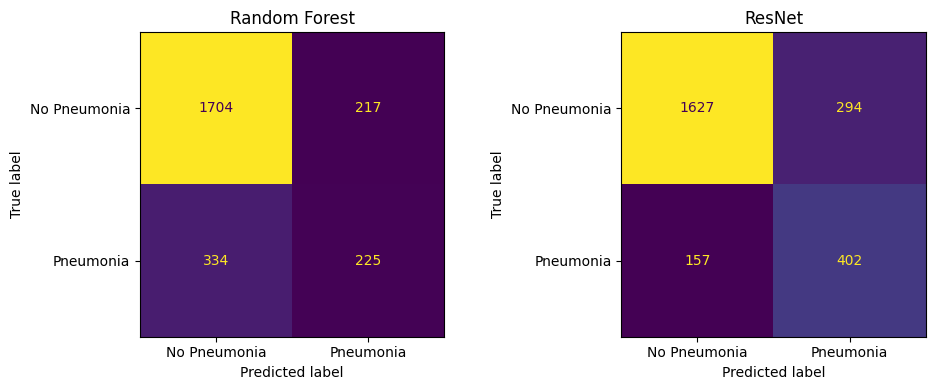

In [59]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

print("Random Forest")
print(rf_results[0])

print("\nResNet")
print(resnet_results[0])

# Plot confusion matrices
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

ConfusionMatrixDisplay(
    confusion_matrix=rf_results[0]["confusion_matrix"],
    display_labels=["No Pneumonia", "Pneumonia"]
).plot(ax=axes[0], values_format="d", colorbar=False)
axes[0].set_title("Random Forest")

ConfusionMatrixDisplay(
    confusion_matrix=resnet_results[0]["confusion_matrix"],
    display_labels=["No Pneumonia", "Pneumonia"]
).plot(ax=axes[1], values_format="d", colorbar=False)
axes[1].set_title("ResNet")

plt.tight_layout()
plt.show()

as we can see the false negative is lower in resnet compared to random forest

In [60]:
results_df = pd.DataFrame({"Random Forest": rf_results[0], "Resnet": resnet_results[0]}).T
results_df

,labels,probabilities,predictions,confusion_matrix,accuracy,sensitivity,specificity,precision,roc_auc,f1_score
Random Forest,"[0.0, 1.0, 0.0, 0.0, 1.0, 0.0, 1.0, 1.0, 1.0, ...","[0.45525510619161014, 0.07078567976843857, 0.1...","[0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, ...","[[1704, 217], [334, 225]]",0.777823,0.402504,0.887038,0.50905,0.780847,0.655187
Resnet,"[0, 1, 0, 0, 1, 0, 1, 1, 1, 1, 0, 0, 1, 0, 0, ...","[0.00498036, 0.06578278, 0.23196544, 0.0001586...","[0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, ...","[[1627, 294], [157, 402]]",0.818145,0.719141,0.846955,0.577586,0.871414,0.759455


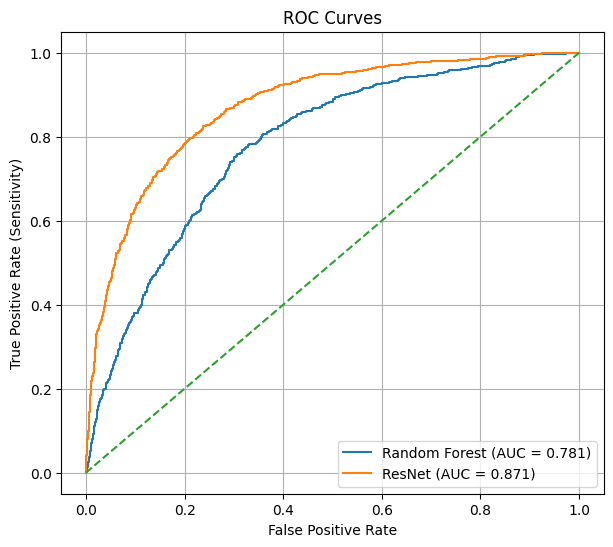

In [61]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

rf_fpr, rf_tpr, _ = roc_curve(rf_results[0]['labels'], rf_results[0]['probabilities'])
resnet_fpr, resnet_tpr, _ = roc_curve(resnet_results[0]['labels'], resnet_results[0]['probabilities'])

rf_auc = roc_auc_score(rf_results[0]['labels'], rf_results[0]['probabilities'])
resnet_auc = roc_auc_score(resnet_results[0]['labels'], resnet_results[0]['probabilities'])

plt.figure(figsize=(7, 6))

plt.plot(
    rf_fpr, rf_tpr,
    label=f"Random Forest (AUC = {rf_auc:.3f})"
)

plt.plot(
    resnet_fpr, resnet_tpr,
    label=f"ResNet (AUC = {resnet_auc:.3f})"
)

plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate (Sensitivity)")
plt.title("ROC Curves")
plt.legend()
plt.grid()
plt.show()

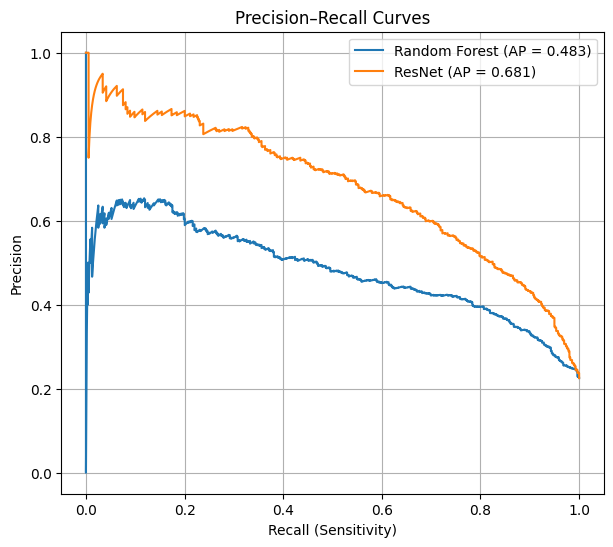

In [62]:
from sklearn.metrics import precision_recall_curve, average_precision_score

rf_precision, rf_recall, _ = precision_recall_curve(rf_results[0]['labels'], rf_results[0]['probabilities'])
resnet_precision, resnet_recall, _ = precision_recall_curve(resnet_results[0]['labels'], resnet_results[0]['probabilities'])

rf_ap = average_precision_score(rf_results[0]['labels'], rf_results[0]['probabilities'])
resnet_ap = average_precision_score(resnet_results[0]['labels'], resnet_results[0]['probabilities'])

plt.figure(figsize=(7, 6))

plt.plot(
    rf_recall, rf_precision,
    label=f"Random Forest (AP = {rf_ap:.3f})"
)

plt.plot(
    resnet_recall, resnet_precision,
    label=f"ResNet (AP = {resnet_ap:.3f})"
)

plt.xlabel("Recall (Sensitivity)")
plt.ylabel("Precision")
plt.title("Precision–Recall Curves")
plt.legend()
plt.grid()
plt.show()

The Precision–Recall curve is more informative for this dataset because healthy cases significantly outnumber positive pneumonia cases. In ROC curves, a large number of true negatives inflates the denominator of the False Positive Rate, making model performance appear deceptively high. In contrast, the Precision–Recall curve isolates the positive class by measuring precision, revealing a clearer picture of false positive errors that ROC curves conceal

### Select Threshold

In [64]:
def get_threshold_metrics(y_true, probabilities, threshold):
    predictions = (probabilities >= threshold).astype(int)

    tn, fp, fn, tp = confusion_matrix(
        y_true, predictions, labels=[0, 1]
    ).ravel()

    sensitivity = tp / (tp + fn)
    specificity = tn / (tn + fp)

    return sensitivity, specificity


def select_thresholds(result):
    y_true = result["labels"]
    probabilities = result["probabilities"]

    thresholds = np.unique(probabilities)

    metrics = []

    for threshold in thresholds:
        sensitivity, specificity = get_threshold_metrics(
            y_true, probabilities, threshold
        )

        metrics.append({
            "threshold": threshold,
            "sensitivity": sensitivity,
            "specificity": specificity
        })

    # Screening:
    # highest threshold that still achieves >= 90% sensitivity
    screening_candidates = [
        x for x in metrics
        if x["sensitivity"] >= 0.90
    ]

    screening = max(
        screening_candidates,
        key=lambda x: x["threshold"]
    )

    # High specificity:
    # lowest threshold that achieves >= 90% specificity
    specificity_candidates = [
        x for x in metrics
        if x["specificity"] >= 0.90
    ]

    high_specificity = min(
        specificity_candidates,
        key=lambda x: x["threshold"]
    )

    return screening, high_specificity

In [ ]:
rf_threshold = select_thresholds(rf_results[0])
resnet_threshold = select_thresholds(resnet_results[0])

print("RF Threshold")
print(rf_threshold) # first one for screening/high sensitivity and second one for high specificity

print("\nResnet Threshold")
print(resnet_threshold)

RF Threshold
({'threshold': np.float64(0.18278192215177264), 'sensitivity': np.float64(0.9016100178890877), 'specificity': np.float64(0.4726704841228527)}, {'threshold': np.float64(0.5157337713462928), 'sensitivity': np.float64(0.3810375670840787), 'specificity': np.float64(0.9000520562207184)})

Resnet Threshold
({'threshold': np.float32(0.16747782), 'sensitivity': np.float64(0.9016100178890877), 'specificity': np.float64(0.6553878188443519)}, {'threshold': np.float32(0.63215333), 'sensitivity': np.float64(0.629695885509839), 'specificity': np.float64(0.9000520562207184)})


In [73]:
# screening

final_rf_model = joblib.load("model/random_forest_seed_1.joblib")
y_test_prob = final_rf_model.predict_proba(X_test)[:, 1]
screening_rf_result = evaluate(y_test, y_test_prob, threshold=rf_threshold[0]['threshold'])

final_resnet_model = make_resnet50()
final_resnet_model.load_state_dict(
    torch.load(
        f"model_weight/best_model_1.pth",
        map_location=DEVICE,
        weights_only=True
    )
)

screening_resnet_result = evaluate_model(
    final_resnet_model,
    test_loader,
    threshold=resnet_threshold[0]['threshold'],
    verbose=False
)

print(screening_rf_result)
print(screening_resnet_result)

print(f"RF sensitivity: {screening_rf_result['sensitivity']}")
print(f"Resnet sensitivity: {screening_resnet_result['sensitivity']}")

{'labels': array([1., 0., 1., ..., 1., 0., 0.], shape=(2546,)), 'probabilities': array([0.3034845 , 0.02481971, 0.49227297, ..., 0.5392007 , 0.41818358,
       0.67552948], shape=(2546,)), 'predictions': array([1, 0, 1, ..., 1, 1, 1], shape=(2546,)), 'confusion_matrix': array([[ 982, 1027],
       [  59,  478]]), 'accuracy': 0.800471327572663, 'sensitivity': 0.8901303538175046, 'specificity': np.float64(0.4888003982080637), 'precision': 0.3176079734219269, 'roc_auc': np.float64(0.7845004741234277), 'f1_score': 0.6696978735923378}
{'labels': array([1, 0, 1, ..., 1, 0, 0], shape=(2546,)), 'probabilities': array([3.9414465e-01, 5.3725590e-04, 9.8443294e-01, ..., 9.5525485e-01,
       1.5578075e-01, 3.4867191e-01], shape=(2546,), dtype=float32), 'predictions': array([1, 0, 1, ..., 1, 0, 1], shape=(2546,)), 'confusion_matrix': array([[1359,  650],
       [  64,  473]]), 'accuracy': 0.8256087981146897, 'sensitivity': 0.8808193668528864, 'specificity': np.float64(0.6764559482329517), 'precisi

In [72]:
# high_specificity

final_rf_model = joblib.load("model/random_forest_seed_1.joblib")
y_test_prob = final_rf_model.predict_proba(X_test)[:, 1]
high_specificity_rf_result = evaluate(y_test, y_test_prob, threshold=rf_threshold[1]['threshold'])

final_resnet_model = make_resnet50()
final_resnet_model.load_state_dict(
    torch.load(
        f"model_weight/best_model_1.pth",
        map_location=DEVICE,
        weights_only=True
    )
)

high_specificity_resnet_result = evaluate_model(
    final_resnet_model,
    test_loader,
    threshold=resnet_threshold[1]['threshold'],
    verbose=False
)

print(high_specificity_rf_result)
print(high_specificity_resnet_result)

print(f"RF specificity: {high_specificity_rf_result['specificity']}")
print(f"Resnet specificity: {high_specificity_resnet_result['specificity']}")

{'labels': array([1., 0., 1., ..., 1., 0., 0.], shape=(2546,)), 'probabilities': array([0.3034845 , 0.02481971, 0.49227297, ..., 0.5392007 , 0.41818358,
       0.67552948], shape=(2546,)), 'predictions': array([0, 0, 0, ..., 1, 0, 1], shape=(2546,)), 'confusion_matrix': array([[1839,  170],
       [ 339,  198]]), 'accuracy': 0.800471327572663, 'sensitivity': 0.3687150837988827, 'specificity': np.float64(0.9153807864609258), 'precision': 0.5380434782608695, 'roc_auc': np.float64(0.7845004741234277), 'f1_score': 0.6696978735923378}
{'labels': array([1, 0, 1, ..., 1, 0, 0], shape=(2546,)), 'probabilities': array([3.9414465e-01, 5.3725590e-04, 9.8443294e-01, ..., 9.5525485e-01,
       1.5578075e-01, 3.4867191e-01], shape=(2546,), dtype=float32), 'predictions': array([0, 0, 1, ..., 1, 0, 0], shape=(2546,)), 'confusion_matrix': array([[1822,  187],
       [ 217,  320]]), 'accuracy': 0.8256087981146897, 'sensitivity': 0.595903165735568, 'specificity': np.float64(0.9069188651070185), 'precisio

We can see that the result transfer the test data, where sensitivity is high in screening and specificity is high in the other one

### Reliability diagram

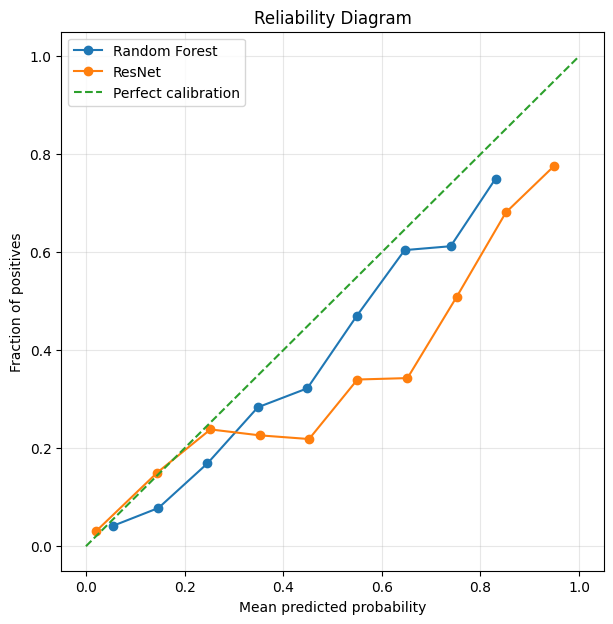

In [69]:
from sklearn.calibration import calibration_curve

# Random Forest
rf_true_prob, rf_pred_prob = calibration_curve(
    screening_rf_result["labels"],
    screening_rf_result["probabilities"],
    n_bins=10,
    strategy="uniform"
)

# ResNet
resnet_true_prob, resnet_pred_prob = calibration_curve(
    screening_resnet_result["labels"],
    screening_resnet_result["probabilities"],
    n_bins=10,
    strategy="uniform"
)

# Plot
plt.figure(figsize=(7, 7))

plt.plot(
    rf_pred_prob,
    rf_true_prob,
    marker="o",
    label="Random Forest"
)

plt.plot(
    resnet_pred_prob,
    resnet_true_prob,
    marker="o",
    label="ResNet"
)

# Perfect calibration
plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Perfect calibration"
)

plt.xlabel("Mean predicted probability")
plt.ylabel("Fraction of positives")
plt.title("Reliability Diagram")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

Here we can see that random forest is actually more calibrated compared to resnet, even though resnet sensitivity/recall is better